# Lecture 7: Kernel Methods: Regression

In [1]:
import polars as pl, numpy as np, matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

In [3]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR

# Hands-on: tons of polynomial features vs RBF kernel

In [4]:
X = np.array([
    [0],[1],[2],[3],[4],[5]
])
print(X)
PolynomialFeatures(4, include_bias=False).fit_transform(X)

[[0]
 [1]
 [2]
 [3]
 [4]
 [5]]


array([[  0.,   0.,   0.,   0.],
       [  1.,   1.,   1.,   1.],
       [  2.,   4.,   8.,  16.],
       [  3.,   9.,  27.,  81.],
       [  4.,  16.,  64., 256.],
       [  5.,  25., 125., 625.]])

In [5]:
PolynomialFeatures(4).fit_transform(X)

array([[  1.,   0.,   0.,   0.,   0.],
       [  1.,   1.,   1.,   1.,   1.],
       [  1.,   2.,   4.,   8.,  16.],
       [  1.,   3.,   9.,  27.,  81.],
       [  1.,   4.,  16.,  64., 256.],
       [  1.,   5.,  25., 125., 625.]])

In [6]:
def my_dataset(N, rng=np.random.RandomState()):
    X = np.sort(-2.5 + 5 * rng.rand(N, 1), axis=0)
    y = np.sin(X).ravel() + 0.2 * rng.randn(N)
    return X, y

In [7]:
def compare_fit(alpha=0.1, N=200, rng=np.random.RandomState(5)):
    X, y = my_dataset(N, rng)
    
    # Fit models
    models = {
        "Linear": make_pipeline(Ridge(alpha)),
        "Poly deg=3": make_pipeline(
            # No bias in features because Ridge has its own bias
            PolynomialFeatures(3, include_bias=False),
            Ridge(alpha)
        ),
        "Poly deg=30": make_pipeline(
            PolynomialFeatures(30, include_bias=False),
            Ridge(alpha)
        ),
        "RBF(1/2)": KernelRidge(alpha, kernel="rbf", gamma=1/2),
        "RBF(4)": KernelRidge(alpha, kernel="rbf", gamma=4),
    }
    
    # Visualization
    plt.figure(figsize=(12, 4))
    for i, (name, model) in enumerate(models.items(), 1):
        model.fit(X, y)
        X_test = np.linspace(-4, 4, 1000).reshape(-1, 1)
        plt.subplot(1, 5, i)
        plt.scatter(X, y, s=10, alpha=0.5)
        plt.plot(X_test, model.predict(X_test), 'r-', lw=2)
        plt.title(name)
        plt.ylim(-1.5, 1.5)
        if i > 1: 
            plt.gca().set_yticks([])
    plt.tight_layout()

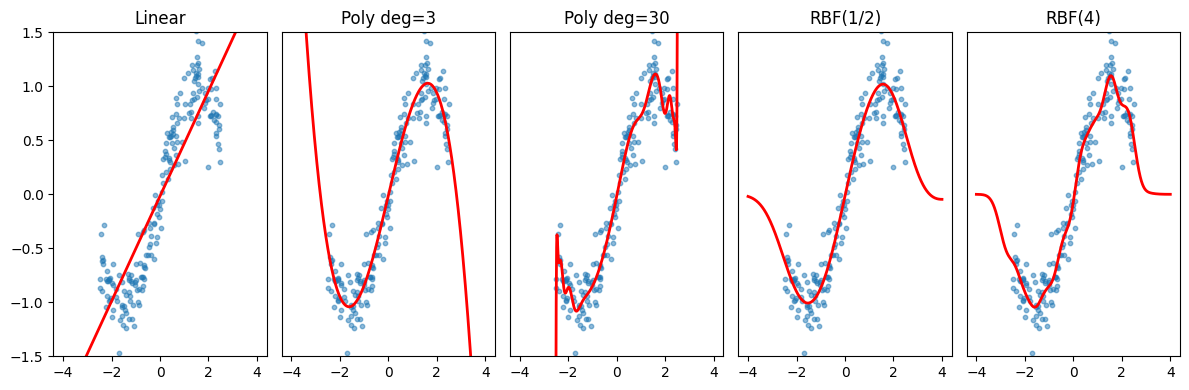

In [8]:
compare_fit()

# Custom `KernelRidge`

Solve the dual problem:
$$
\begin{aligned}
\max_{a \in \mathbb{R}^N} &&&-\frac{1}{2} a^\top \left( K + \frac{1}{C} I \right) a + a^\top y\\
\text{s.t.} &&& \sum_n a_n = 0
\end{aligned}
$$
Where $K_{n,m} = \phi(x_n)^\top \phi(x_m)$ is the kernel matrix.

Lagrangian:
$$
\mathcal L = \frac{1}{2} a^\top \left( K + \frac{1}{C} I \right) a - a^\top y + \lambda a^\top 1
$$

1. Stationarity: $a = (K + \frac{1}{C} I)^{-1} (y - 1 \lambda)$.
2. Primal feasibility: $1^\top a = 0$. $$\lambda = \frac{1^\top (K + \frac{1}{C} I)^{-1} y}{1^\top (K + \frac{1}{C} I)^{-1} 1}$$
3. Substitute this $\lambda$ to get the dual variables $$\begin{aligned}a &= \left(K + \frac{1}{C} I\right)^{-1} (y - 1 \lambda)\\ &= \left(K + \frac{1}{C} I\right)^{-1} y - \left(K + \frac{1}{C} I\right)^{-1} 1 \lambda\end{aligned}$$

Note that we already computed $t_1 = \left(K + \frac{1}{C} I\right)^{-1} y$ and $t_2 = \left(K + \frac{1}{C} I\right)^{-1} 1$ when computing $\lambda$.

In [1]:
def solve_KernelRidge(K, y, C: float):
    M = K + 1/C * np.eye(*K.shape)
    # Solve (K + 1/C I) t1 = y
    t1 = ...
    # Solve (K + 1/C I) t1 = 1 (vector [1,1,1,...,1])
    t2 = ...

    lmb = ...
    a = t1 - t2 * lmb
    return a # dual solution

In [10]:
class MyKernelRidge:
    """Ridge regression with RBF kernel.

    Parameters:
    - `C > 0`: _inverse_ of regularization strength.
    According to https://scikit-learn.org/stable/modules/generated/sklearn.kernel_ridge.KernelRidge.html,
    "Alpha corresponds to 1 / (2C) in other linear models".
    - `gamma >= 0` or `None`: parameter of RBF kernel.
    """
    def __init__(self, C: float, gamma=None):
        assert C > 0
        self.C, self.gamma = C, gamma

    def fit(self, X, y):
        X, y = np.array(X), np.array(y)
        K = rbf_kernel(X, gamma=self.gamma)
        self.X_ = X # store full training dataset!!
        self.dual_coef_ = solve_KernelRidge(K, y, self.C)
        self.intercept_ = ...
        return self

    def predict(self, X_new):
        X_new = np.atleast_2d(X_new)
        K = rbf_kernel(self.X_, X_new)
        return self.intercept_ + ...

In [11]:
# Generate random dataset
X, y = my_dataset(200, np.random.RandomState(1))
X_test = np.linspace(X.min()-1, X.max()+1, 500)[:, None]

In [12]:
MyKernelRidge(2).fit(X, y).intercept_

np.float64(-0.01324307708727066)

__Important__: RBF operates in an infinite-dimensional space (in particular, weights $w = \sum_n a_n \phi(x_n)$ are _infinite-dimensional_), but we computed everything:
- on a finite computer!
- in finite time!

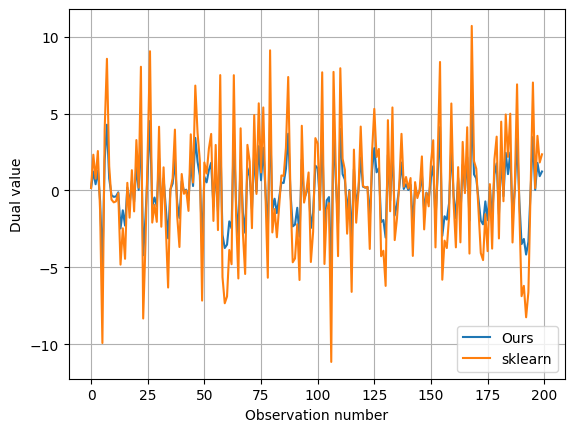

In [13]:
C = 10
plt.plot(MyKernelRidge(C).fit(X, y).dual_coef_, label="Ours")
# Alpha corresponds to 1 / (2C) in other linear models
plt.plot(KernelRidge(alpha=1/(2 * C), kernel='rbf').fit(X, y).dual_coef_, label="sklearn")
plt.legend(); plt.grid()
plt.xlabel('Observation number'); plt.ylabel('Dual value');

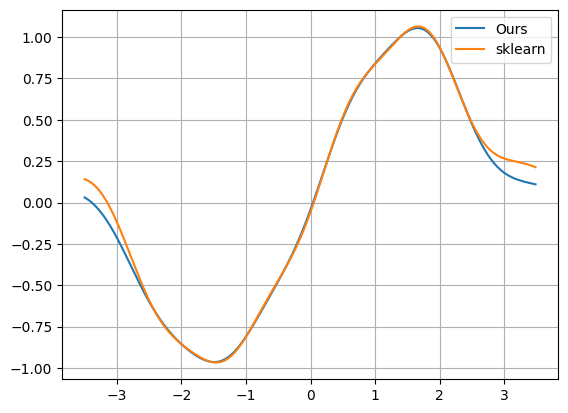

In [14]:
C = 10
model_ours = MyKernelRidge(C).fit(X, y)
# Alpha corresponds to 1 / (2C) in other linear models
model_sklearn = KernelRidge(alpha=1/(2 * C), kernel='rbf').fit(X, y)
plt.plot(X_test.flat, model_ours.predict(X_test), label="Ours")
plt.plot(X_test.flat, model_sklearn.predict(X_test), label="sklearn")
plt.legend(); plt.grid();

# Apply to real-life dataset

In [15]:
df = (
    pl.read_csv("https://github.com/Michael-tehc/MachineLearning-MSU/raw/refs/heads/main/data/Housing.csv")
    .with_columns(
        pl.col('price', 'area').log(),
        pl.col('mainroad guestroom basement'.split()).replace_strict({
            'yes': 1, 'no': 0
        })
    )
)
df

price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
f64,f64,i64,i64,i64,i64,i64,i64,str,str,i64,str,str
16.403275,8.911934,4,2,3,1,0,0,"""no""","""yes""",2,"""yes""","""furnished"""
16.321036,9.100526,4,4,4,1,0,0,"""no""","""yes""",3,"""no""","""furnished"""
16.321036,9.206332,3,2,2,1,0,1,"""no""","""no""",2,"""yes""","""semi-furnished"""
16.318175,8.922658,4,2,2,1,0,1,"""no""","""yes""",3,"""yes""","""furnished"""
16.250001,8.911934,4,1,2,1,1,1,"""no""","""yes""",2,"""no""","""furnished"""
…,…,…,…,…,…,…,…,…,…,…,…,…
14.414347,8.006368,2,1,1,1,0,1,"""no""","""no""",2,"""no""","""unfurnished"""
14.384879,7.783224,3,1,1,0,0,0,"""no""","""no""",0,"""no""","""semi-furnished"""
14.375126,8.194229,2,1,1,1,0,0,"""no""","""no""",0,"""no""","""unfurnished"""


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X2, y2 = df.select(
    'area bedrooms bathrooms stories mainroad basement'.split()
).to_numpy(), df['price'].to_numpy()
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, test_size=0.1, random_state=5)

In [18]:
def loglik_gauss(ys, locations, scale: float=1):
    zs = (ys - locations) / scale
    return (
        -0.5 * np.log(2 * np.pi) - np.log(scale) - 0.5 * zs**2
    ).sum()

def loglik_insensitive(ys, eps: float, locations, scale=1):
    zs = (ys - locations) / scale
    return (
        -np.log(2 * (1 + eps)) - np.log(scale) - np.maximum(0, abs(zs) - eps)
    ).sum()

In [19]:
def NLL_KernelRidge(Xtrain, ytrain, Xval, yval, gamma, C):
    # Don't forget to scale the inputs!
    model = ...
    return {
        'train': -loglik_gauss(ytrain, model.predict(Xtrain)),
        'val': -loglik_gauss(yval, model.predict(Xval)),
    }

## What values of $\gamma$ can cause overfitting?

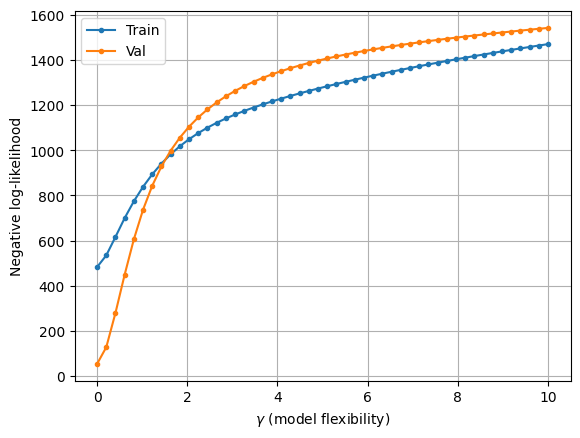

In [20]:
# Low gamma => more fine details
gammas = np.linspace(1e-5, 10, 50)
nlls = [
    NLL_KernelRidge(X2_train, y2_train, X2_val, y2_val, gamma, 1.5)
    for gamma in gammas
]
nlls_train = [p['train'] for p in nlls]
nlls_val = [p['val'] for p in nlls]
plt.plot(gammas, nlls_train, '.-', label='Train')
plt.plot(gammas, nlls_val, '.-', label='Val')
plt.legend(); plt.grid()
plt.xlabel(r"$\gamma$ (model flexibility)")
plt.ylabel("Negative log-likelihood");

In [21]:
def plot_overfit(Xtrain, Xtest, ytrain, ytest):
    # Task: Vary gamma for RBF kernel and plot test MSE
    X_train_scaled = ...
    X_test_scaled = ...
    gammas = np.logspace(-2, 1, 10)
    loss_vals = []
    for g in gammas:
        model = KernelRidge(alpha=0.1, kernel='rbf', gamma=g)
        model.fit(X_train_scaled, ytrain)
        loss_vals.append(
            -loglik_gauss(ytest, model.predict(X_test_scaled))
        )
    
    plt.semilogx(gammas, loss_vals, 'o-')
    plt.xlabel("gamma (RBF width)")
    plt.ylabel("Test loss")
    plt.title(r"Kernel sensitivity: Too small $\to$ underfit, too large $\to$ overfit")

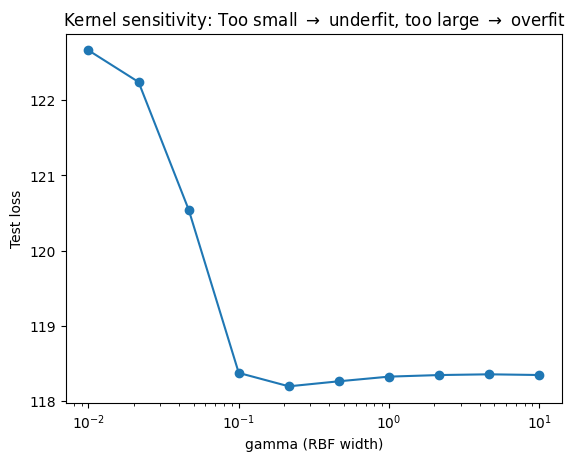

In [22]:
plot_overfit(
    *train_test_split(*my_dataset(500))
);

# Support vector regression with $\varepsilon$-insensitive loss

Scaling is especially crucial for the $\varepsilon$-insensitive loss because $\epsilon$ should not depend on the scale of the data.

In [23]:
# High epsilon => more sparse solution
for eps in [0.5, 0.6, 0.7, 0.8, 0.9, 1]:
    model = ...
    print(f"{eps=} =>", model.dual_coef_.shape[1], "support vectors")
    print(model.dual_coef_.flatten()); print()

eps=0.5 => 36 support vectors
[ 0.09837553  0.44445799  0.43294442  0.80662315  0.22845765  0.18933514
  0.05344344  4.          4.          0.22308491  0.13262065  0.17051832
  1.07342099  4.          0.21418498  0.03409531  0.0160241  -0.07205087
 -0.17865149 -0.10973315 -0.29572081 -0.27743297 -0.00743619 -1.69998283
 -0.53728823 -0.10726944 -0.07062467 -0.03399966 -3.4753481  -4.
 -0.25263023 -0.09878927 -0.2997885  -0.34270285 -0.25813732 -4.        ]

eps=0.6 => 21 support vectors
[ 0.24764796  0.33337538  0.13096813  0.1370505   0.13118437  0.06564051
  0.98826573  4.          3.8601528  -0.36534939 -0.97506881 -3.68367955
 -0.0183809  -0.22558366 -0.01267972 -0.08719804 -0.1396792  -0.06548997
 -0.19240038 -0.12877576 -4.        ]

eps=0.7 => 14 support vectors
[ 0.31611661  0.22457119  0.12913972  0.14764356  0.04773511  0.03297263
 -0.14746203 -0.00816536 -0.0499153  -0.19074194 -0.09660281 -0.02465751
 -0.07135777 -0.30927611]

eps=0.8 => 10 support vectors
[ 0.22884639  0.1

## What values of $\varepsilon$ can cause overfitting?

Try to overfit SVR by varying epsilon.
What values of epsilon correspond to more flexible models?

In [24]:
# ???